# **EfficientNetB0 for Plant Disease Detection**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install efficientnet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.1 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from efficientnet.tfkeras import EfficientNetB0
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Set your data and model paths
data_dir = '/content/drive/MyDrive/disease/Plant_images'
model_path = '/content/efficientnet_model.h5'

# Set parameters
batch_size = 32
image_size = (224, 224)  # EfficientNetB0 input size
epochs = 20

In [ ]:
# Data preprocessing
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 4398 images belonging to 11 classes.
Found 1099 images belonging to 11 classes.


In [ ]:
# Create the EfficientNetB0 model
base_model = EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

16804768/16804768 [==============================] - 0s 0us/step


In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Implement early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
# Train the model
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator, callbacks=[early_stopping])

Epoch 1/20
138/138 [==============================] - 1793s 13s/step - loss: 0.4611 - accuracy: 0.8677 - val_loss: 0.0779 - val_accuracy: 0.9836
Epoch 2/20
138/138 [==============================] - 19s 139ms/step - loss: 0.0982 - accuracy: 0.9739 - val_loss: 0.0429 - val_accuracy: 0.9927
Epoch 3/20
138/138 [==============================] - 19s 138ms/step - loss: 0.0533 - accuracy: 0.9884 - val_loss: 0.0262 - val_accuracy: 0.9927
Epoch 4/20
138/138 [==============================] - 19s 140ms/step - loss: 0.0448 - accuracy: 0.9893 - val_loss: 0.0216 - val_accuracy: 0.9936
Epoch 5/20
138/138 [==============================] - 19s 140ms/step - loss: 0.0322 - accuracy: 0.9916 - val_loss: 0.0177 - val_accuracy: 0.9955
Epoch 6/20
138/138 [==============================] - 18s 133ms/step - loss: 0.0252 - accuracy: 0.9948 - val_loss: 0.0219 - val_accuracy: 0.9927
Epoch 7/20
138/138 [==============================] - 19s 135ms/step - loss: 0.0287 - accuracy: 0.9927 - val_loss: 0.0138 - val_ac

In [ ]:
# Save the model
model.save(model_path)

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

35/35 [==============================] - 7s 184ms/step - loss: 0.0111 - accuracy: 0.9964
Validation Accuracy: 99.64%


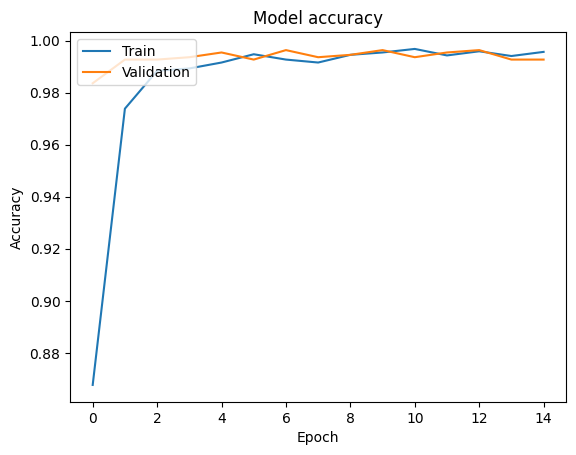

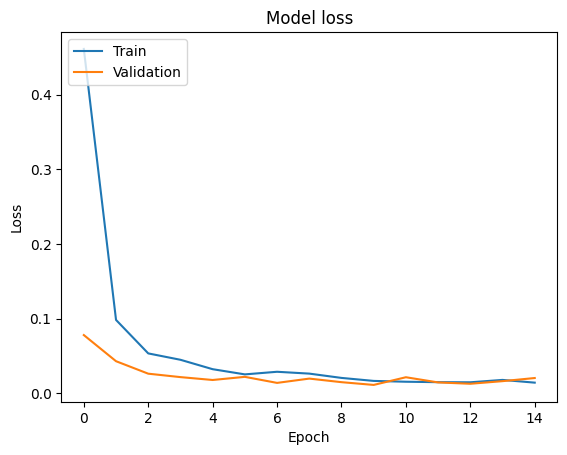

In [ ]:
# Visualize training history
def plot_training_history(history):
    # Plot training & validation accuracy values
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

    # Plot training & validation loss values
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

plot_training_history(history)

35/35 [==============================] - 5s 105ms/step


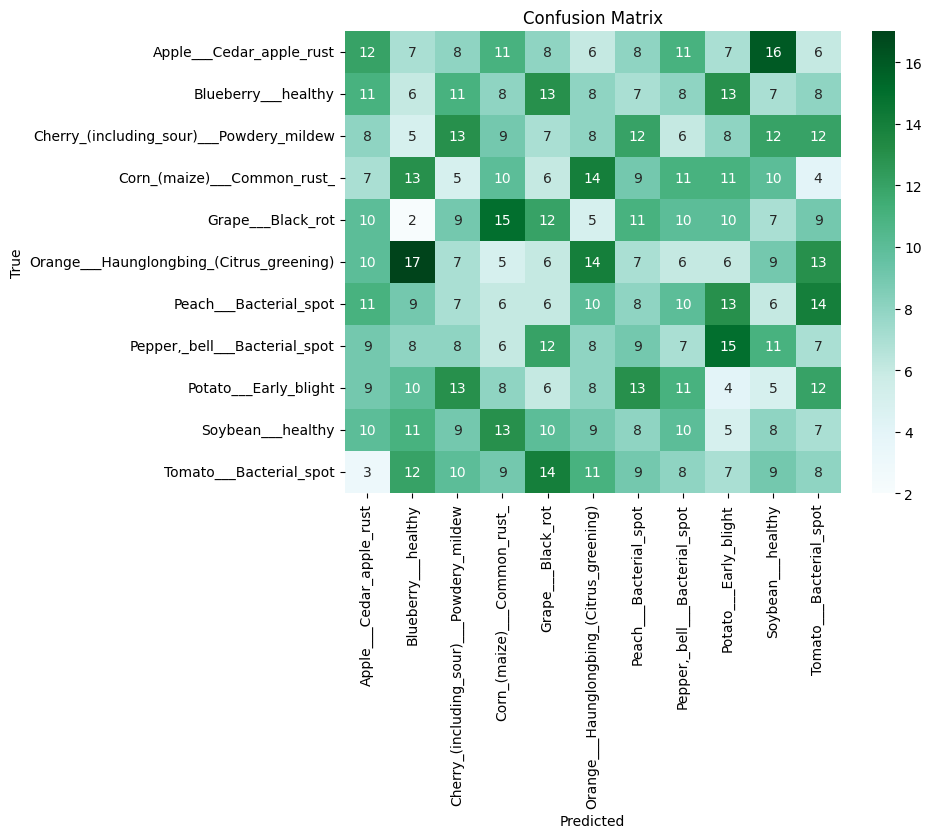

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
# Generate predictions
y_true = validation_generator.classes
y_pred = np.argmax(model.predict(validation_generator), axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='BuGn', xticklabels=train_generator.class_indices.keys(), yticklabels=train_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# Classification report
class_labels = list(train_generator.class_indices.keys())
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))


Classification Report:
                                           precision    recall  f1-score   support

                Apple___Cedar_apple_rust       0.12      0.12      0.12       100
                     Blueberry___healthy       0.06      0.06      0.06       100
Cherry_(including_sour)___Powdery_mildew       0.13      0.13      0.13       100
             Corn_(maize)___Common_rust_       0.10      0.10      0.10       100
                       Grape___Black_rot       0.12      0.12      0.12       100
Orange___Haunglongbing_(Citrus_greening)       0.14      0.14      0.14       100
                  Peach___Bacterial_spot       0.08      0.08      0.08       100
           Pepper,_bell___Bacterial_spot       0.07      0.07      0.07       100
                   Potato___Early_blight       0.04      0.04      0.04        99
                       Soybean___healthy       0.08      0.08      0.08       100
                 Tomato___Bacterial_spot       0.08      0.08      0.08 